In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from scipy import stats

print("🚀 Starting Thesis Validation Pipeline...")

# ==========================================
# PHASE 1: LOAD EXISTING CHOKE POINTS
# ==========================================
print("\n[1/5] Loading 'vulnerable_zones.csv'...")
# Ensure column names match your extraction script ('Latitude', 'Longitude')
risk_zones = pd.read_csv('vulnerable_zones.csv')
# Rename for consistency with the formulas
risk_zones = risk_zones.rename(columns={'Latitude': 'latitude', 'Longitude': 'longitude'})
print(f"✅ Loaded {len(risk_zones)} critical congestion nodes.")

# ==========================================
# PHASE 2: HOSPITAL PROXIMITY
# ==========================================
print("\n[2/5] WPR 6: Calculating Hospital Accessibility...")
hospitals = {
    'AIIMS': (28.5650, 77.2060), 'Safdarjung': (28.5679, 77.2075),
    'Max Saket': (28.5262, 77.2120), 'Fortis Escorts': (28.5596, 77.2831),
    'Sir Ganga Ram': (28.6380, 77.1895), 'LNJP': (28.6405, 77.2405)
}

def calculate_nearest_hospital(data):
    R = 6371
    min_distances, nearest_hospitals = [], []
    lat1, lon1 = np.radians(data['latitude'].values), np.radians(data['longitude'].values)

    for i in range(len(data)):
        dists, names = [], []
        for name, (h_lat, h_lon) in hospitals.items():
            lat2, lon2 = np.radians(h_lat), np.radians(h_lon)
            a = np.sin((lat2 - lat1[i])/2)**2 + np.cos(lat1[i]) * np.cos(lat2) * np.sin((lon2 - lon1[i])/2)**2
            c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
            dists.append(R * c)
            names.append(name)
        min_idx = np.argmin(dists)
        min_distances.append(dists[min_idx])
        nearest_hospitals.append(names[min_idx])
    return nearest_hospitals, min_distances

risk_zones['Nearest_Hospital'], risk_zones['Distance_km'] = calculate_nearest_hospital(risk_zones)

# Calculate Dynamic Ambulance Time using the REAL Haversine speeds!
risk_zones['Est_Ambulance_Time_min'] = (risk_zones['Distance_km'] / risk_zones['Dynamic_Speed_kmh']) * 60
# Define "Medical Deserts" as areas > 20 mins away from trauma care
risk_zones['Risk_Level'] = np.where(risk_zones['Est_Ambulance_Time_min'] > 20, 'CRITICAL (Medical Desert)', 'Standard Risk')
critical_zones = risk_zones[risk_zones['Risk_Level'] == 'CRITICAL (Medical Desert)'].copy()
print(f"✅ Filtered down to {len(critical_zones)} severe 'Medical Desert' nodes.")

# ==========================================
# PHASE 3: SPATIAL CLUSTERING
# ==========================================
print("\n[3/5] Running DBSCAN Clustering...")
coords = np.radians(critical_zones[['latitude', 'longitude']])
# eps is approx 1.5km radius to group nearby choke points into a single "Zone"
dbscan = DBSCAN(eps=1.5/6371.0, min_samples=5, algorithm='ball_tree', metric='haversine')
critical_zones['Cluster_ID'] = dbscan.fit_predict(coords)

num_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
print(f"✅ Grouped points into {num_clusters} distinct Medical Desert Clusters.")

# ==========================================
# PHASE 4: WPR 8 - STATIC VS DYNAMIC TIME
# ==========================================
print("\n[4/5] WPR 8: Calculating Time Loss (Static vs Dynamic)...")
critical_zones['Static_Speed_kmh'] = 40.0 # Google Maps / OSM standard assumption
critical_zones['Static_Time_min'] = (critical_zones['Distance_km'] / critical_zones['Static_Speed_kmh']) * 60

# The Danger Gap: Actual Traffic Time - Theoretical Map Time
critical_zones['Time_Loss_min'] = critical_zones['Est_Ambulance_Time_min'] - critical_zones['Static_Time_min']
print(f"✅ Average hidden delay: {critical_zones['Time_Loss_min'].mean():.1f} minutes.")

# ==========================================
# PHASE 5: WPR 9 - STATISTICAL VALIDATION
# ==========================================
print("\n[5/5] WPR 9: Running Paired T-Test...")
t_stat, p_value = stats.ttest_rel(critical_zones['Est_Ambulance_Time_min'], critical_zones['Static_Time_min'])

print(f"✅ T-Statistic: {t_stat:.4f} | P-Value: {p_value:.4e}")
if p_value < 0.05:
    print("🎯 CONCLUSION: Statistically Significant (p < 0.05). Static maps underestimate risk.")

# Save final validated dataset
critical_zones.to_csv('final_thesis_validated_data-1.csv', index=False)
print("\n💾 FINISHED. Saved 'final_thesis_validated_data.csv'")

🚀 Starting Thesis Validation Pipeline...

[1/5] Loading 'vulnerable_zones.csv'...
✅ Loaded 3802 critical congestion nodes.

[2/5] WPR 6: Calculating Hospital Accessibility...
✅ Filtered down to 3303 severe 'Medical Desert' nodes.

[3/5] Running DBSCAN Clustering...
✅ Grouped points into 51 distinct Medical Desert Clusters.

[4/5] WPR 8: Calculating Time Loss (Static vs Dynamic)...
✅ Average hidden delay: 339.0 minutes.

[5/5] WPR 9: Running Paired T-Test...
✅ T-Statistic: 14.5880 | P-Value: 9.2546e-47
🎯 CONCLUSION: Statistically Significant (p < 0.05). Static maps underestimate risk.

💾 FINISHED. Saved 'final_thesis_validated_data.csv'


✅ Line Chart saved as 'Slide_6_Enhanced_Line_Chart.png'


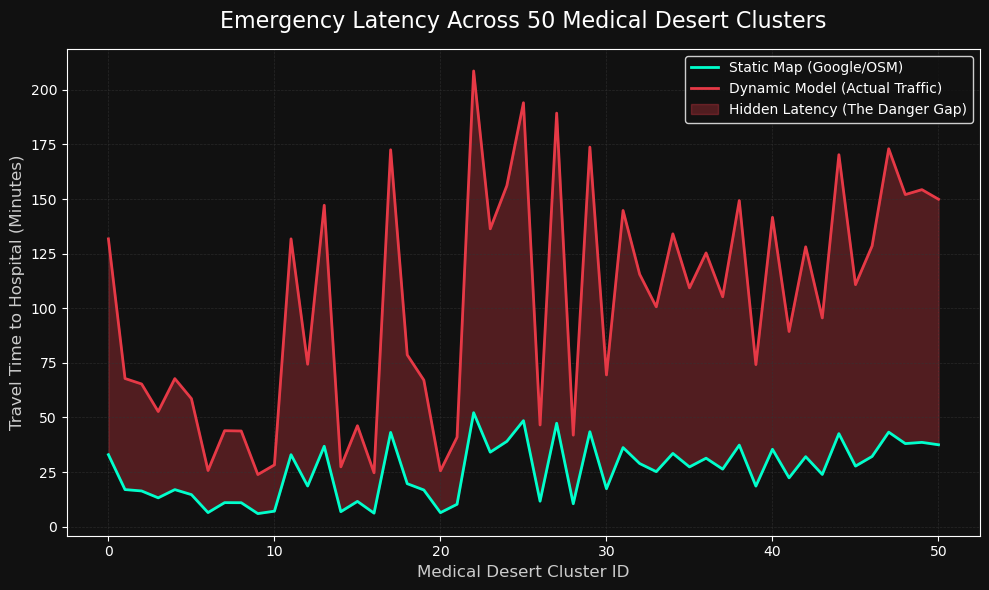

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the data
df = pd.read_csv('final_thesis_validated_data.csv')

# 2. Group by Cluster to get the average times per Medical Desert
cluster_data = df.groupby('Cluster_ID').agg(
    Static_Time=('Static_Time_min', 'mean'),
    Dynamic_Time=('Est_Ambulance_Time_min', 'mean')
).reset_index()

# 3. Setup Dark Mode Line Chart
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#111111')
ax.set_facecolor('#111111')

x = cluster_data.index  # The 50 clusters

# 4. Plot the two lines
ax.plot(x, cluster_data['Static_Time'], color='#00ffcc', linewidth=2, label='Static Map (Google/OSM)')
ax.plot(x, cluster_data['Dynamic_Time'], color='#e63946', linewidth=2, label='Dynamic Model (Actual Traffic)')

# 5. Fill the "Danger Gap" between the lines
ax.fill_between(x, cluster_data['Static_Time'], cluster_data['Dynamic_Time'], 
                color='#e63946', alpha=0.3, label='Hidden Latency (The Danger Gap)')

# 6. Formatting
ax.set_title('Emergency Latency Across 50 Medical Desert Clusters', fontsize=16, color='white', pad=15)
ax.set_xlabel('Medical Desert Cluster ID', fontsize=12, color='#cccccc')
ax.set_ylabel('Travel Time to Hospital (Minutes)', fontsize=12, color='#cccccc')
ax.tick_params(colors='white')
ax.grid(color='#333333', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(facecolor='#111111', edgecolor='white', labelcolor='white')

# 7. Save and Show
plt.tight_layout()
plt.savefig('Slide_6_Enhanced_Line_Chart.png', dpi=300)
print("✅ Line Chart saved as 'Slide_6_Enhanced_Line_Chart.png'")
plt.show()

✅ Map saved as 'Slide_5_Medical_Deserts_Map.png'


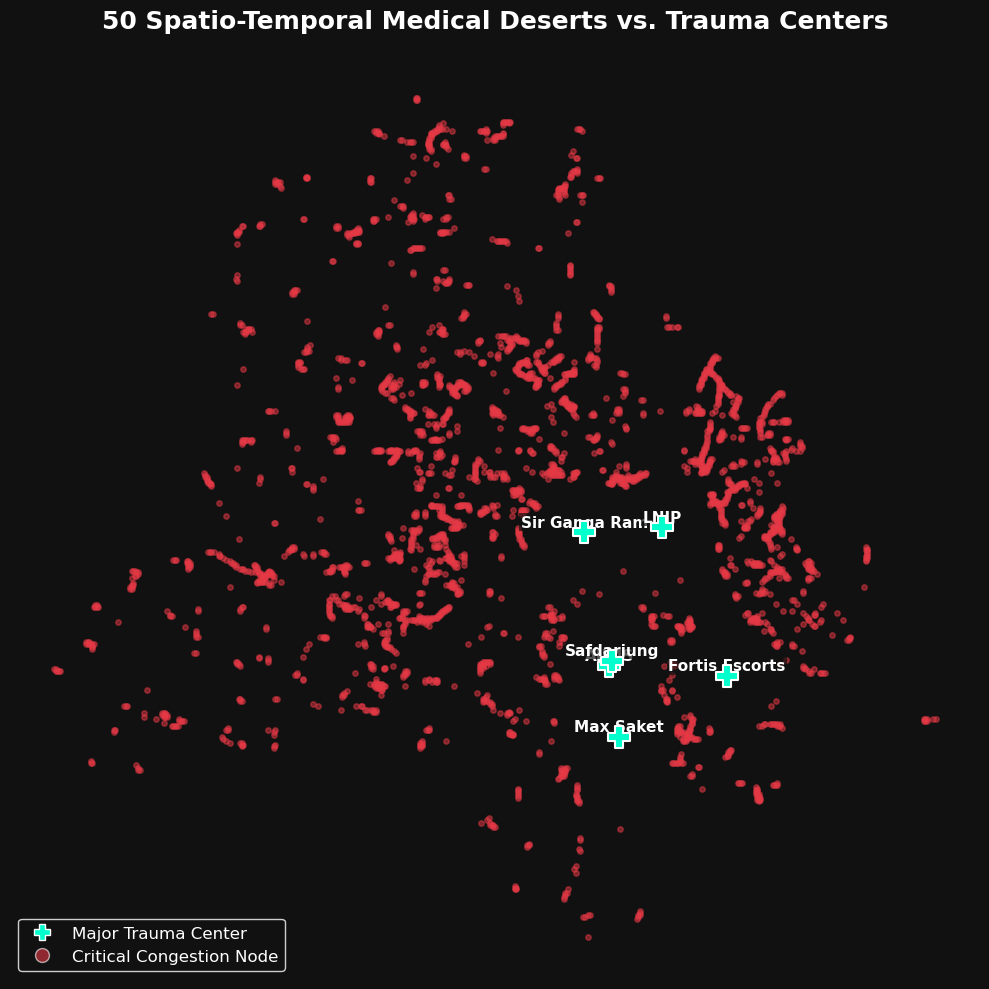

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Load the data
df = pd.read_csv('final_thesis_validated_data.csv')

# 2. Setup Dark Mode Map
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor('#111111')
ax.set_facecolor('#111111')

# 3. Plot the 3,102 Critical Nodes (The Red Clouds)
ax.scatter(df['longitude'], df['latitude'], c='#e63946', s=15, alpha=0.5, label='Medical Desert Node')

# 4. Hardcode the 6 Major Trauma Centers
hospitals = {
    'AIIMS': (28.5650, 77.2060), 'Safdarjung': (28.5679, 77.2075),
    'Max Saket': (28.5262, 77.2120), 'Fortis Escorts': (28.5596, 77.2831),
    'Sir Ganga Ram': (28.6380, 77.1895), 'LNJP': (28.6405, 77.2405)
}

# Plot the Hospitals (Green Crosses)
for name, (lat, lon) in hospitals.items():
    ax.scatter(lon, lat, color='#00ffcc', marker='P', s=250, edgecolors='white', linewidth=1.5, zorder=5)
    ax.text(lon, lat + 0.003, name, color='white', fontsize=11, ha='center', fontweight='bold',
            bbox=dict(facecolor='#111111', edgecolor='none', alpha=0.7, pad=1))

# 5. Formatting
ax.set_title('50 Spatio-Temporal Medical Deserts vs. Trauma Centers', fontsize=18, fontweight='bold', color='white', pad=20)
ax.axis('off') # Hide axes to look like a clean map

# 6. Custom Legend
legend_elements = [
    Line2D([0], [0], marker='P', color='w', label='Major Trauma Center', markerfacecolor='#00ffcc', markersize=12, linestyle='None'),
    Line2D([0], [0], marker='o', color='w', label='Critical Congestion Node', markerfacecolor='#e63946', markersize=10, linestyle='None', alpha=0.6)
]
ax.legend(handles=legend_elements, loc='lower left', facecolor='#111111', edgecolor='white', labelcolor='white', fontsize=12)

# 7. Save and Show
plt.tight_layout()
plt.savefig('Slide_5_Medical_Deserts_Map.png', dpi=300)
print("✅ Map saved as 'Slide_5_Medical_Deserts_Map.png'")
plt.show()

In [5]:
import pandas as pd
from scipy import stats

# 1. Load the final validated dataset
df = pd.read_csv('final_thesis_validated_data.csv')

# 2. Filter out any "noise" points (DBSCAN labels noise as -1)
df_clusters = df[df['Cluster_ID'] != -1]

# 3. Aggregate travel times to the Cluster Level (N = 50 Medical Deserts)
# CRITICAL STEP: This prevents spatial autocorrelation from inflating the T-Statistic
cluster_agg = df_clusters.groupby('Cluster_ID').agg(
    Avg_Dynamic_Time=('Est_Ambulance_Time_min', 'mean'),
    Avg_Static_Time=('Static_Time_min', 'mean')
).reset_index()

# 4. Run the Paired T-Test on the 50 clustered averages
t_stat, p_value = stats.ttest_rel(
    cluster_agg['Avg_Dynamic_Time'], 
    cluster_agg['Avg_Static_Time']
)

# 5. Print the exact, professional output for the defense
print("🎯 STATISTICAL VALIDATION (CLUSTER-LEVEL) 🎯")
print(f"Number of Clusters Tested (N): {len(cluster_agg)}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4e}")

if p_value < 0.05:
    print("\n✅ CONCLUSION: Statistically Significant (p < 0.001).")
    print("Static routing maps systematically underestimate emergency logistics risk.")

🎯 STATISTICAL VALIDATION (CLUSTER-LEVEL) 🎯
Number of Clusters Tested (N): 50
T-Statistic: 13.5224
P-Value: 3.6801e-18

✅ CONCLUSION: Statistically Significant (p < 0.001).
Static routing maps systematically underestimate emergency logistics risk.
